## Data Quality Assessment:
We have decided that it would be best to conduct the data quality assessment and subsequent data cleaning before data integration to allow for the most effective integration. As a result, we discuss distinct aspects between the spotify dataset and million song dataset. Regarding overall structure, we will assess quality through the lens of accuracy, completeness, consistency, and timeliness. 

### Accuracy
Both datasets seem to be syntactically accurate as evidenced by observing the different attribute data types. In both datasets, attributes such as song duration, energy, key are all integers, as they should be, fields such as danceability, energy, and tempo are correctly labeled as floats, and string variables such as the artist, song, and album name are correctly stored as objects. 

Regarding semantic accuracy, one main concern in the spotify dataset is that there are 16,020 songs (roughly 14.05%) in the dataset with a popularity of 0. However, it is clear that many of these songs shouldn’t have a popularity of 0. For example, Jasson Mraz’s song ‘93 million miles’ has over 200 million streams as of 2025. According to the data dictionary, popularity is most heavily based on “the number of plays the track has had and how recent the plays are”. A song with over 200 million streams shouldn’t have a popularity of 0, leading us to believe these popularities of 0 are inaccurate and instead should represent missing values. Given that our research question is centered around popularity, we likely can’t consider these rows. Additionally, both the spotify and million song datasets have instances of tempo’s of 0. This would be a concern, as that is inaccurate. However, our final integrated dataset doesn’t contain any instance of tempos of 0, so it is not a concern for our use case.

One concern for semantic accuracy in the million song dataset is that the energy and danceability for every song is listed as 0. Similarly, the year column contains 5320 values of 0, equal to roughly 53.19 percent. These instances of 0s are clearly inaccurate, are effectively missing, and can’t be used during analysis.

One final consideration for accuracy is that these datasets were originally created using the Spotify web API and from the million dataset. While we can’t truly confirm the origin of these datasets, the fact that they are cited as being drawn from these credible sources gives us confidence that the data correctly corresponds to the ground truth.. Overall, aside from a few considerations that can be addressed during data cleaning, we believe that these datasets have strong accuracy. 


### Completeness
There is only one row in the spotify dataset with labeled missing data. However, this row also has a popularity of 0, so it will not be considered in our final model. Additionally, as mentioned above, the popularity field does have effectively missing values, which are represented by a popularity of 0. This will need to be addressed during data cleaning. 

The million song dataset does have some missing values in 4 columns: ArtistLatitude (1903 missing values), ArtistLocation(1131), ArtistLongitude (1903), and mbID (8). The mbID missing is not a large concern because this identifier will not serve any value, since it is not in the spotify dataset. The larger concern would be for the artist's latitude, longitude, and location. To address this, we will choose to not consider these variables during analysis by not carrying them over during data integration. Additionally, as mentioned above, in the million song dataset, the energy, danceability, and year columns have large amounts of effectively missing data as well and will need to be removed during the data cleaning process.

One final consideration is that while these two datasets contain a large amount of data,114,000 and 10,001 rows in the spotify and million song datasets respectively, this data doesn’t include all the songs that data could be collected on. However, both dataset’s songs are fairly evenly distributed across different genres and the Spotify songs include a wide range of song popularities, and the million song dataset shows that it covers a wide range of different years. As such, we believe these datasets are representative and sufficient to conduct a proper analysis on.

Overall, the missing values in popularity will need to be addressed in the spotify dataset, and missing values in ArtistLatitude, ArtistLocation, ArtistLongitude, and Year will need to be addressed in the million song dataset. Once these concerns are addressed, we believe that this data exhibits very strong completeness.

### Consistency 
With the exception of tempo and the million song dataset’s year column, which have already been discussed, there do not seem to be any clear domain violations within either dataset. For example, in the spotify dataset song popularities all fall between 0 and 100, energy and danceability scores are all between 0.0 and 1.0, and key indications are all between 0 and 11. Similarly, in the million song dataset, artist familiarity and hotness fall between 0.0 and 1.0 and all keys are between 0 and 11. There are no clear semantic constraints between attributes that need to be considered in either dataset. Both datasets are stored in a csv and are each represented as one single table, so there is no concern of inter-relation constraints being violated for either dataset. Overall, the consistency of this dataset seems strong.

### Timeliness
Both datasets are static datasets, meaning that their contents will not ever be updated. However, for the most part, this is not a concern. The data has incredibly low volatility, as the attributes such as artist and song title do not change for songs, and the audio features gathered are almost never updated for songs once they are created for both original sources (the spotify api and million song dataset). One additional consideration is that the spotify dataset has not been updated since 2023, and the million song dataset doesn’t contain any songs more recent than 2010. As a result, it is fair to say that they are not the most current datasets. However, we don’t believe this is necessarily an issue, as long as finders are interpreted accordingly.


## Documented Steps to Profile Data
Below find the results of the steps we took to profile our data. The is the foundation from which our quality analysis was built off of. Please refer to the comments for more information

### Spotify Dataset

Our first step was to view all datatypes and summary statsitics for each attribute in this dataset.

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
df_spotify = pd.read_csv("../data/raw/SpotifyRaw.csv", index_col=0)
print(df_spotify.dtypes)
display(df_spotify.describe(include='all'))


track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
count,114000,113999,113999,113999,114000.000000,1.140000e+05,114000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000
unique,89741,31437,46589,73608,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,acoustic
freq,9,279,195,151,NaN,NaN,104253,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1000
mean,NaN,NaN,NaN,NaN,33.238535,2.280292e+05,NaN,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035,NaN
std,NaN,NaN,NaN,NaN,22.305078,1.072977e+05,NaN,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621,NaN
min,NaN,NaN,NaN,NaN,0.000000,0.000000e+00,NaN,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,17.000000,1.740660e+05,NaN,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000,NaN
50%,NaN,NaN,NaN,NaN,35.000000,2.129060e+05,NaN,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000,NaN
75%,NaN,NaN,NaN,NaN,50.000000,2.615060e+05,NaN,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000,NaN


Below is our assessment of all missing values

In [2]:
display(pd.DataFrame({
    "missing": df_spotify.isna().sum(),
    "missing_pct": (df_spotify.isna().mean() * 100).round(2)
}))
display(df_spotify[df_spotify.isnull().any(axis=1)])

,missing,missing_pct
track_id,0,0.0
artists,1,0.0
album_name,1,0.0
track_name,1,0.0
popularity,0,0.0
duration_ms,0,0.0
explicit,0,0.0
danceability,0,0.0
energy,0,0.0
key,0,0.0


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


After seeing that the popularity and tempo fields had a minimum of 0, we investigated these issues further

In [3]:
print("Number of Songs with popularity of 0: ", len(df_spotify[df_spotify["popularity"] == 0]))
print("Percentage of Songs with popularity of 0: ", 100*len(df_spotify[df_spotify["popularity"] == 0])/len(df_spotify))
print("Number of Songs with a temp of 0: ", 100*len(df_spotify[df_spotify["tempo"] == 0]))
print("Percentage of Songs with tempo of 0: ", len(df_spotify[df_spotify["tempo"] == 0])/len(df_spotify))

df_spotify[df_spotify["popularity"] == 0].head()

Number of Songs with popularity of 0:  16020
Percentage of Songs with popularity of 0:  14.052631578947368
Number of Songs with a temp of 0:  15700
Percentage of Songs with tempo of 0:  0.0013771929824561403


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
23,0BUuuEvNa5T4lMaewyiudB,Jason Mraz,Coffee Moment,93 Million Miles,0,216386,False,0.572,0.454,3,-10.286,1,0.0258,0.4770,0.000014,0.0974,0.515,140.182,4,acoustic
24,3Hn3LfhrQOaKihdCibJsTs,Jason Mraz,Human - Best Adult Pop Tunes,Unlonely,0,231266,False,0.796,0.667,5,-4.831,0,0.0392,0.3810,0.000000,0.2210,0.754,97.988,4,acoustic
26,5IfCZDRXZrqZSm8AwE44PG,Jason Mraz,Holly Jolly Christmas,Winter Wonderland,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.7880,0.000000,0.1460,0.664,145.363,4,acoustic
27,0dzKBptH2P5j5a0MifBMwM,Jason Mraz,Feeling Good - Adult Pop Favorites,If It Kills Me,0,273653,False,0.633,0.429,4,-6.784,0,0.0381,0.0444,0.000000,0.1320,0.520,143.793,4,acoustic
28,5QAMZTM5cmLg3fHX9ZbTZi,Jason Mraz,Christmas Time,Winter Wonderland,0,131760,False,0.620,0.309,5,-9.209,1,0.0495,0.7880,0.000000,0.1460,0.664,145.363,4,acoustic


We examined duplicate values, both complete duplicates and duplicate song titles & artist combinations

In [4]:
df_spotify["ArtistLower"] = df_spotify["artists"].str.lower()
df_spotify["SongLower"] = df_spotify["track_name"].str.lower()

display(df_spotify[df_spotify.duplicated(keep=False)].sort_values(["ArtistLower", "SongLower"]))
display(df_spotify[df_spotify.duplicated(subset=["ArtistLower", "SongLower"], keep=False)].sort_values(["ArtistLower", "SongLower"]))

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,ArtistLower,SongLower
9351,1hB4340DP1nnBmfWn37uTN,509-E;Dexter;Afro-X,Provérbios 13,Saudades Mil,48,526026,True,0.624,0.5890,2,...,0.2810,0.302000,0.000000,0.1240,0.780,76.847,4,brazil,509-e;dexter;afro-x,saudades mil
9407,1hB4340DP1nnBmfWn37uTN,509-E;Dexter;Afro-X,Provérbios 13,Saudades Mil,48,526026,True,0.624,0.5890,2,...,0.2810,0.302000,0.000000,0.1240,0.780,76.847,4,brazil,509-e;dexter;afro-x,saudades mil
13704,14vexXpojwu3mG1S9fqHmL,Aaron Smith;Luvli,Dancin,Dancin - Laidback Luke Remix,20,381395,False,0.664,0.8480,6,...,0.1620,0.075900,0.033200,0.1060,0.359,129.056,4,chicago-house,aaron smith;luvli,dancin - laidback luke remix
13754,14vexXpojwu3mG1S9fqHmL,Aaron Smith;Luvli,Dancin,Dancin - Laidback Luke Remix,20,381395,False,0.664,0.8480,6,...,0.1620,0.075900,0.033200,0.1060,0.359,129.056,4,chicago-house,aaron smith;luvli,dancin - laidback luke remix
47484,17lu4tymfnhmcIDlzBbtAb,AC/DC,For Those About to Rock (We Salute You),For Those About to Rock (We Salute You),67,344240,False,0.370,0.9190,4,...,0.1020,0.000376,0.419000,0.4900,0.471,134.021,4,hard-rock,ac/dc,for those about to rock (we salute you)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93451,4RLEptaOiYYtnZ07Nq87k2,Надежда Обухова;Матвей Сахаров,Песни советских композиторов,Осенние листья,0,208202,False,0.281,0.0665,9,...,0.0495,0.988000,0.000012,0.0904,0.159,74.017,3,romance,надежда обухова;матвей сахаров,осенние листья
93273,1RTNUU0YYocc0YwoLkEMq6,Николай Рыбников,4 ноября. День народного единства,"Марш высотников - Из к/ф ""Высота""",0,53472,False,0.653,0.4660,5,...,0.0666,0.748000,0.000040,0.3220,0.882,121.245,4,romance,николай рыбников,"марш высотников - из к/ф ""высота"""
93304,1RTNUU0YYocc0YwoLkEMq6,Николай Рыбников,4 ноября. День народного единства,"Марш высотников - Из к/ф ""Высота""",0,53472,False,0.653,0.4660,5,...,0.0666,0.748000,0.000040,0.3220,0.882,121.245,4,romance,николай рыбников,"марш высотников - из к/ф ""высота"""
93405,4w0kFToo4KieF43IMDb9ED,Татьяна Комова;Георгий Квик,Ромэн. Русские цыганские романсы,Солнышко,0,214373,False,0.306,0.2020,9,...,0.0333,0.978000,0.047900,0.2150,0.174,79.701,4,romance,татьяна комова;георгий квик,солнышко


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,ArtistLower,SongLower
58516,5h7RBt7uQCF788tr9Zy92j,(Hed) P.E.,Broke,Crazy Legs,25,242800,False,0.607,0.775,6,...,0.2670,0.001950,0.000001,0.0915,0.736,102.051,4,industrial,(hed) p.e.,crazy legs
58857,5igKQzi92vVl9Pjj86d42O,(Hed) P.E.,Broke,Crazy Legs,22,242960,True,0.523,0.810,6,...,0.2940,0.001840,0.000001,0.0744,0.738,102.863,4,industrial,(hed) p.e.,crazy legs
58306,7kv31DonKok7StOsCdvoBT,(Hed) P.E.,Broke,Waiting to Die,27,194800,True,0.581,0.962,8,...,0.1210,0.000262,0.000011,0.1320,0.484,115.226,4,industrial,(hed) p.e.,waiting to die
58874,0aiP8ezzmk3W1GRvnQYDCA,(Hed) P.E.,Broke,Waiting to Die,22,194626,False,0.577,0.964,2,...,0.1200,0.000276,0.000048,0.1550,0.533,115.250,4,industrial,(hed) p.e.,waiting to die
63488,3KYALFgiqZLKScioJGqz8a,10-FEET,VANDALIZE,SHOES,34,137893,False,0.517,0.981,9,...,0.1100,0.069000,0.000000,0.0610,0.654,124.821,4,j-rock,10-feet,shoes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102361,6la3Kme7O7D01fJPxgpAS5,詹雯婷,訣愛,訣愛 (劇集《蒼蘭訣》片頭曲),69,189295,False,0.450,0.620,11,...,0.0365,0.313000,0.000000,0.0672,0.169,142.026,4,songwriter,詹雯婷,訣愛 (劇集《蒼蘭訣》片頭曲)
12466,1o7LoJTQd4Js16rHjTKAc9,陳秋霞,第二道彩虹,六月天,23,178493,False,0.487,0.414,10,...,0.0282,0.438000,0.000004,0.3490,0.745,141.018,4,cantopop,陳秋霞,六月天
70920,1o7LoJTQd4Js16rHjTKAc9,陳秋霞,第二道彩虹,六月天,23,178493,False,0.487,0.414,10,...,0.0282,0.438000,0.000004,0.3490,0.745,141.018,4,mandopop,陳秋霞,六月天
62250,1dGF5ymTyBB2ZmOypkeU1F,須田景凪,porte,veil,63,209636,False,0.559,0.873,0,...,0.0543,0.028100,0.000000,0.1850,0.797,150.055,4,j-pop,須田景凪,veil


Finally, to detemine if our sample was representative, we observed the distributions of song popularity and genre

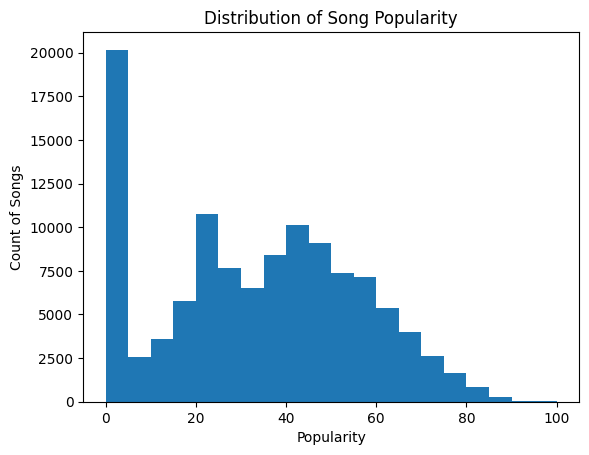

Total Number of Genres: 114


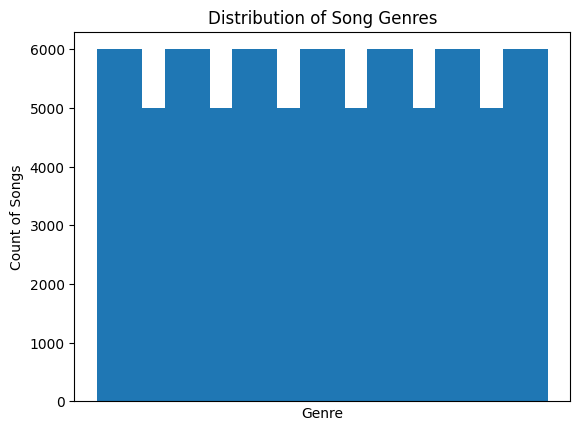

In [5]:
plt.hist(df_spotify['popularity'], bins=20)
plt.xlabel("Popularity")
plt.ylabel("Count of Songs")
plt.title("Distribution of Song Popularity")
plt.show()

print("Total Number of Genres:", df_spotify['track_genre'].nunique())
plt.hist(df_spotify['track_genre'], bins=20)
plt.xlabel("Genre")
plt.xticks([])
plt.ylabel("Count of Songs")
plt.title("Distribution of Song Genres")
plt.show()

### Million Song Dataset

Similarly to the spotify dataset, our first step was to view all datatypes and summary statsitics for each attribute in this dataset.

In [6]:
df_million_song = pd.read_csv("../data/raw/MillionSongRaw.csv")
display(df_million_song.describe(include='all'))
print(df_million_song.dtypes)

,SongNumber,SongID,AlbumID,AlbumName,ArtistID,ArtistLatitude,ArtistLocation,ArtistLongitude,ArtistName,Danceability,...,Energy,ArtistFamiliarity,Hotness,end_of_fade_in,key,keyConfidence,Loudness,mode,mode_confidence,start_of_fade_out
count,10001.000000,10001,10001.000000,10001,10001,3742.000000,5709,3742.000000,10001,10001.0,...,10001.0,9997.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000,10001.000000
unique,NaN,10000,NaN,7834,3888,NaN,1029,NaN,4412,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,SOVLGJY12A8C13FBED,NaN,Greatest Hits,AROIHOI122988FEB8E,NaN,London England,NaN,Mario Rosenstock,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,2,NaN,21,13,NaN,149,NaN,13,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5001.000000,NaN,371018.762424,NaN,NaN,37.157357,NaN,-63.933358,NaN,0.0,...,0.0,0.565477,0.385571,0.758564,5.276072,0.449584,-10.484951,0.691131,0.477786,229.980019
std,2887.184355,NaN,236757.658582,NaN,NaN,15.598494,NaN,50.508223,NaN,0.0,...,0.0,0.160168,0.143653,1.867866,3.553910,0.274962,5.399995,0.462050,0.191245,112.191050
min,1.000000,NaN,63.000000,NaN,NaN,-41.280540,NaN,-162.436500,NaN,0.0,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-51.643000,0.000000,0.000000,1.044000
25%,2501.000000,NaN,172858.000000,NaN,NaN,33.748310,NaN,-93.291560,NaN,0.0,...,0.0,0.467620,0.325305,0.000000,2.000000,0.225000,-13.163000,0.000000,0.360000,168.856000
50%,5001.000000,NaN,333103.000000,NaN,NaN,38.997920,NaN,-80.237420,NaN,0.0,...,0.0,0.563749,0.380756,0.199000,5.000000,0.469000,-9.380000,1.000000,0.487000,213.879000
75%,7501.000000,NaN,573497.000000,NaN,NaN,43.648560,NaN,-9.401020,NaN,0.0,...,0.0,0.668020,0.453882,0.421000,8.000000,0.659000,-6.531000,1.000000,0.606000,266.292000


SongNumber                   int64
SongID                      object
AlbumID                      int64
AlbumName                   object
ArtistID                    object
ArtistLatitude             float64
ArtistLocation              object
ArtistLongitude            float64
ArtistName                  object
Danceability               float64
Duration                   float64
KeySignature                 int64
KeySignatureConfidence     float64
Tempo                      float64
TimeSignature                int64
TimeSignatureConfidence    float64
Title                       object
Year                         int64
mbID                        object
Energy                     float64
ArtistFamiliarity          float64
Hotness                    float64
end_of_fade_in             float64
key                          int64
keyConfidence              float64
Loudness                   float64
mode                         int64
mode_confidence            float64
start_of_fade_out   

We also looked into missing values in the dataset

In [7]:
display(pd.DataFrame({
    "missing": df_million_song.isna().sum(),
    "missing_pct": (df_million_song.isna().mean() * 100).round(2)
}))

,missing,missing_pct
SongNumber,0,0.00
SongID,0,0.00
AlbumID,0,0.00
AlbumName,0,0.00
ArtistID,0,0.00
ArtistLatitude,6259,62.58
ArtistLocation,4292,42.92
ArtistLongitude,6259,62.58
ArtistName,0,0.00
Danceability,0,0.00


We also looked into the extent of the issues in the year and tempo columns

In [8]:
print("Number of Songs with year of 0:", len(df_million_song[df_million_song["Year"] == 0]))
print("Percentage of Songs with year of 0:", 100*len(df_million_song[df_million_song["Year"] == 0])/len(df_million_song))

print("Number of Songs with year of 0:", len(df_million_song[df_million_song["Tempo"] == 0]))
print("Percentage of Songs with year of 0:", 100*len(df_million_song[df_million_song["Tempo"] == 0])/len(df_million_song))

Number of Songs with year of 0: 5320
Percentage of Songs with year of 0: 53.19468053194681
Number of Songs with year of 0: 25
Percentage of Songs with year of 0: 0.24997500249975002


We also examined duplicate values, both complete duplicates and duplicate song titles & artist combinations

In [9]:
df_million_song["ArtistLower"] = df_million_song["ArtistName"].str.lower()
df_million_song["SongLower"] = df_million_song["Title"].str.lower()

display(df_million_song[df_million_song.duplicated(keep=False)].sort_values(["ArtistLower", "SongLower"]))
display(df_million_song[df_million_song.duplicated(subset=["ArtistLower", "SongLower"], keep=False)].sort_values(["ArtistLower", "SongLower"]))

,SongNumber,SongID,AlbumID,AlbumName,ArtistID,ArtistLatitude,ArtistLocation,ArtistLongitude,ArtistName,Danceability,...,Hotness,end_of_fade_in,key,keyConfidence,Loudness,mode,mode_confidence,start_of_fade_out,ArtistLower,SongLower


,SongNumber,SongID,AlbumID,AlbumName,ArtistID,ArtistLatitude,ArtistLocation,ArtistLongitude,ArtistName,Danceability,...,Hotness,end_of_fade_in,key,keyConfidence,Loudness,mode,mode_confidence,start_of_fade_out,ArtistLower,SongLower
4122,4123,SODBJKJ12AB0183292,795296,Feelin` Alone,ARN5MQ11187B98A12D,NaN,NaN,NaN,2-Gether feat. Sarinah,0.0,...,0.406432,0.000,11,0.382,-6.380,0,0.369,288.328,2-gether feat. sarinah,feelin` alone
8514,8515,SOFTXGJ12AB018327C,795296,Feelin` Alone,ARPNQ6G1187FB3E286,NaN,NaN,NaN,2-Gether feat. Sarinah,0.0,...,0.365890,0.224,11,0.367,-6.074,0,0.411,186.758,2-gether feat. sarinah,feelin` alone
1358,1359,SOMBLEC12A6D4F5761,37506,S.O.S.,ARIQZ2V1187B98E546,NaN,NaN,NaN,A-Studio,0.0,...,0.362572,0.270,1,0.558,-7.625,1,0.402,172.664,a-studio,s.o.s.
6427,6428,SOQSXAT12A6D4F5760,37505,S.O.S.,ARIQZ2V1187B98E546,NaN,NaN,NaN,A-Studio,0.0,...,0.362572,0.000,0,0.211,-9.657,1,0.316,414.424,a-studio,s.o.s.
2936,2937,SOLIERS12A58A75718,525924,Power Trance Vol. 4,ARXWBOL11E2835E5BB,NaN,NaN,NaN,Abbott & Chambers,0.0,...,0.218936,0.000,7,0.668,-6.466,1,0.768,486.243,abbott & chambers,where are you
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7706,7707,SOKRLDX12A8C140A0F,371780,Live in Tokyo  May 10th_ 1992,ARHBWOZ1187FB3FD53,NaN,ITALY,NaN,Utopia,0.0,...,0.430300,0.000,2,0.746,-20.101,1,0.696,417.158,utopia,hiroshima
301,302,SOYZHTW12A58A7DAD9,722546,White Feather,ARDF8K01187FB37200,NaN,Sydney Australia,NaN,Wolfmother,0.0,...,0.566972,0.705,4,0.006,-6.183,1,0.267,304.036,wolfmother,white feather
1534,1535,SOCHXAE12AF72A25D6,722546,White Feather,ARDF8K01187FB37200,NaN,Sydney Australia,NaN,Wolfmother,0.0,...,0.566972,0.868,4,0.372,-5.931,0,0.207,209.438,wolfmother,white feather
6508,6509,SOKRMOC12AC46885E3,688863,Wings Of Love Remixes,AREYEW21187FB45C47,NaN,NaN,NaN,Zagar feat. Underground Divas,0.0,...,0.399471,0.136,7,0.897,-5.540,1,0.806,305.162,zagar feat. underground divas,wings of love


Finally, to detemine if our sample was representative, we observed the distributions of song year and artist familiarity

count    10001.000000
mean       934.811219
std        996.657859
min          0.000000
25%          0.000000
50%          0.000000
75%       2000.000000
max       2010.000000
Name: Year, dtype: float64

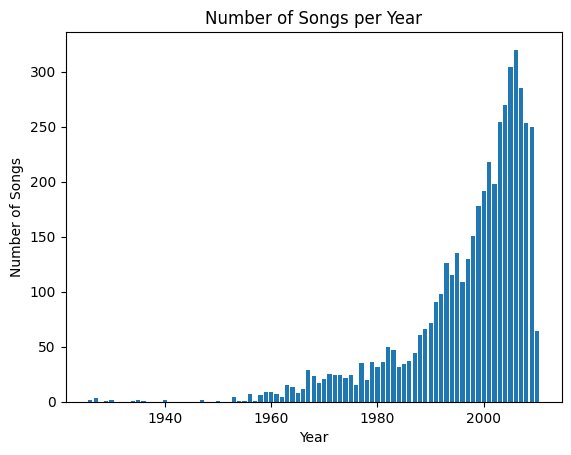

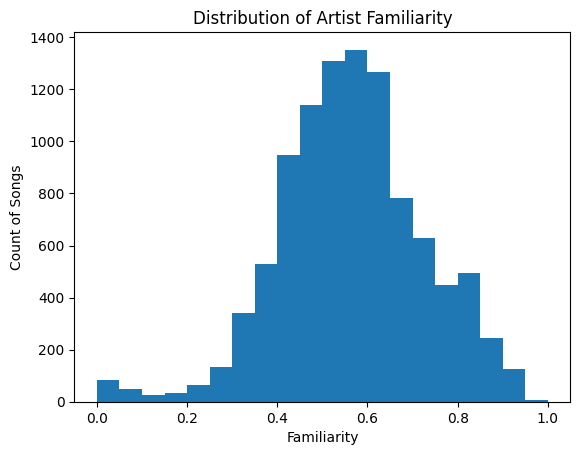

In [10]:
display(df_million_song["Year"].describe())

million_song_songs_per_year = df_million_song[df_million_song['Year'] != 0]['Year'].value_counts().sort_index()

plt.bar(million_song_songs_per_year.index, million_song_songs_per_year.values)
plt.xlabel('Year')
plt.ylabel('Number of Songs')
plt.title('Number of Songs per Year')
plt.show()

plt.hist(df_million_song['ArtistFamiliarity'], bins=20)
plt.xlabel("Familiarity")
plt.ylabel("Count of Songs")
plt.title("Distribution of Artist Familiarity")
plt.show()
